
# E‑commerce Sales Forecasting (Daily Revenue Prediction)

## Project Objective
The goal of this project is to build a machine learning model that can **predict daily sales revenue for an e‑commerce platform**.

Businesses rely on sales forecasting to:

- Plan inventory
- Prepare logistics and delivery operations
- Schedule staff
- Forecast revenue
- Plan marketing campaigns

In this project we use historical transaction data to understand **sales patterns over time** and train models that learn these patterns.

---

## Dataset
We use the **Olist Brazilian E‑commerce Dataset** which contains real transaction data.

Two tables are required for this project:

1. **Orders dataset**
   - Contains the timestamp of when orders were placed.

2. **Order items dataset**
   - Contains the product price and shipping cost.

These datasets are merged using **order_id** to combine order date with revenue information.

---

## Problem Type

This is a **regression problem** because the target variable (revenue) is a continuous value.

We compare two machine learning models:

- Linear Regression
- Random Forest Regressor

The objective is to evaluate which model predicts daily sales more accurately.



## Project Workflow

1. Import libraries
2. Load datasets
3. Inspect and clean data
4. Merge datasets
5. Create revenue feature
6. Aggregate daily sales
7. Feature engineering (time features)
8. Exploratory data analysis
9. Train‑test split (chronological)
10. Train machine learning models
11. Evaluate model performance
12. Visualize predictions
13. Derive business insights


<h1> Ecommerce Sales Forecasting - Regression Project - End to End ML project</h1>

Predict future daily sales revenue for an e-commerce platform using historical transaction data and compare machine learning models to identify the most accurate forecasting approach.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the data
orders = pd.read_csv('datasets/olist_orders_dataset.csv')
order_items = pd.read_csv('datasets/olist_order_items_dataset.csv')

In [3]:
# inspecting the dataset
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [6]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [7]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


<h2> Now let's select the columns we actually need </h2>

<p> From orders we need - order_id and order_purchase_timestamp </p>
<p> and from order_items we need - order_id, price and freight_value </p>

In [8]:
df_orders = orders[['order_id', 'order_purchase_timestamp']]

df_order_items = order_items[['order_id', 'price' , 'freight_value']]

<h1> Now, Lets convert date column from string to datetime</h1>
<p> But before that let's check if there are any duplicates or missing values </p>

In [9]:
df_order_items.isnull().sum()

order_id         0
price            0
freight_value    0
dtype: int64

In [10]:
df_orders.isnull().sum()

order_id                    0
order_purchase_timestamp    0
dtype: int64

In [11]:
df_orders.duplicated().sum()

np.int64(0)

In [12]:
df_order_items['order_id'].duplicated().sum()
# Here duplictaes are expected because In e-commerce, one order can contain multiple products. Example: Customer places one order, but buys 3 items.

np.int64(13984)

In [13]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'], errors = 'coerce')

In [14]:
# created a date column
df_orders['date'] = df_orders['order_purchase_timestamp'].dt.date

<h1> Merge the datasets </h1>

In [15]:
df = pd.merge(df_orders, df_order_items, on = 'order_id', how = 'inner')

In [16]:
df.shape

(112650, 5)

In [17]:
df.head()

,order_id,order_purchase_timestamp,date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-02,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07-24,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-08,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-11-18,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-13,19.90,8.72


<h1> Create a Revenue Column </h1>

In [18]:
df['revenue'] = df['price'] + df['freight_value']

<h1> Aggregate to daily sales</h1>
<p> Prediction target is daily revenue. </p>

In [19]:
daily_sales = df.groupby('date')['revenue'].sum().reset_index()
daily_sales.head()

,date,revenue
0,2016-09-04,136.23
1,2016-09-05,75.06
2,2016-09-15,143.46
3,2016-10-02,109.34
4,2016-10-03,595.14


<p> Now, we have a time series dataset </p>

<h1> Convert date back to datetime </h1>

In [20]:
daily_sales['date'] = pd.to_datetime(df['date'], errors = 'coerce')

<h1> Create time features </h1>
<p> These are your model features. </p>

In [21]:
daily_sales["month"] = daily_sales["date"].dt.month
daily_sales["day"] = daily_sales["date"].dt.day
daily_sales["weekday"] = daily_sales["date"].dt.weekday

In [22]:
daily_sales['is_weekend'] = daily_sales['weekday'].isin([5,6]).astype(int)

<h1> Visualize trends </h1>
<p> Daily Sales Trend </p>

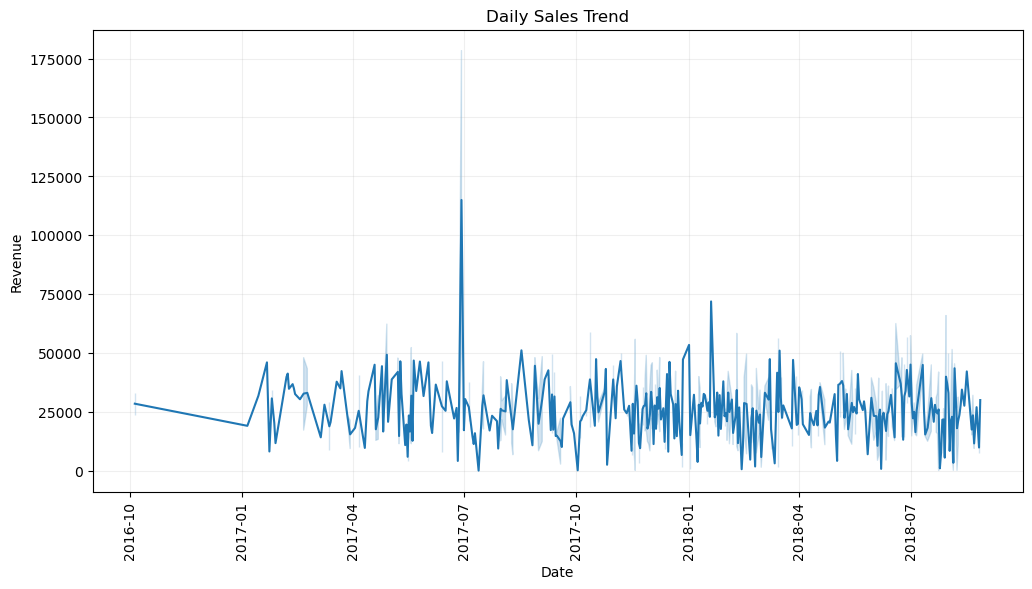

In [24]:
plt.figure(figsize = (12,6))
sns.lineplot(x = 'date', y = 'revenue', data = daily_sales)
plt.xlabel('Date')
plt.xticks(rotation = 90)
plt.ylabel('Revenue')
plt.title('Daily Sales Trend')
plt.grid(True, alpha = 0.2)
plt.show()

Montly Sales

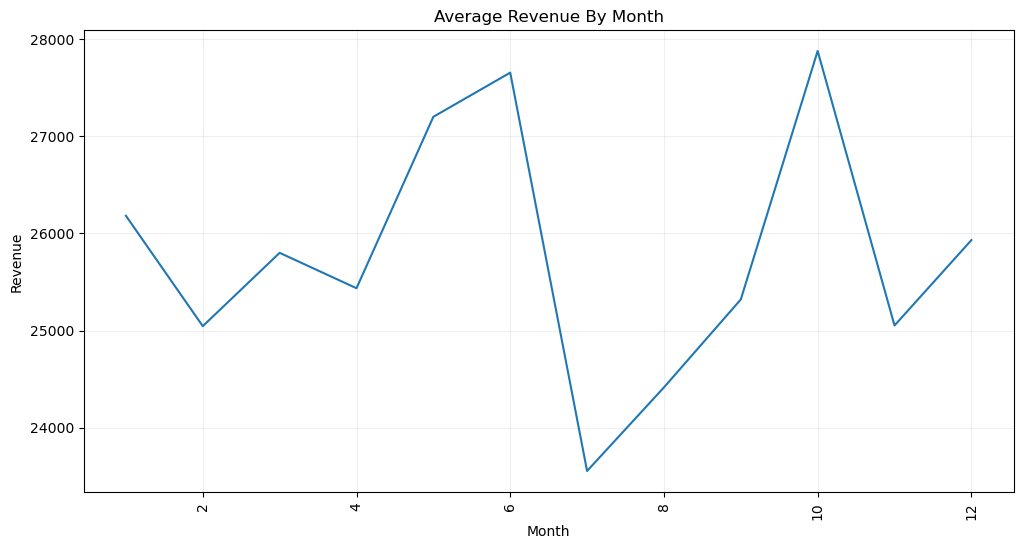

In [25]:
monthly_sales = daily_sales.groupby('month')['revenue'].mean().reset_index()

plt.figure(figsize = (12,6))
sns.lineplot(x = 'month', y = 'revenue', data = monthly_sales)
plt.xlabel('Month')
plt.xticks(rotation = 90)
plt.ylabel('Revenue')
plt.title('Average Revenue By Month')
plt.grid(True, alpha = 0.2)
plt.show()

Weekday sales

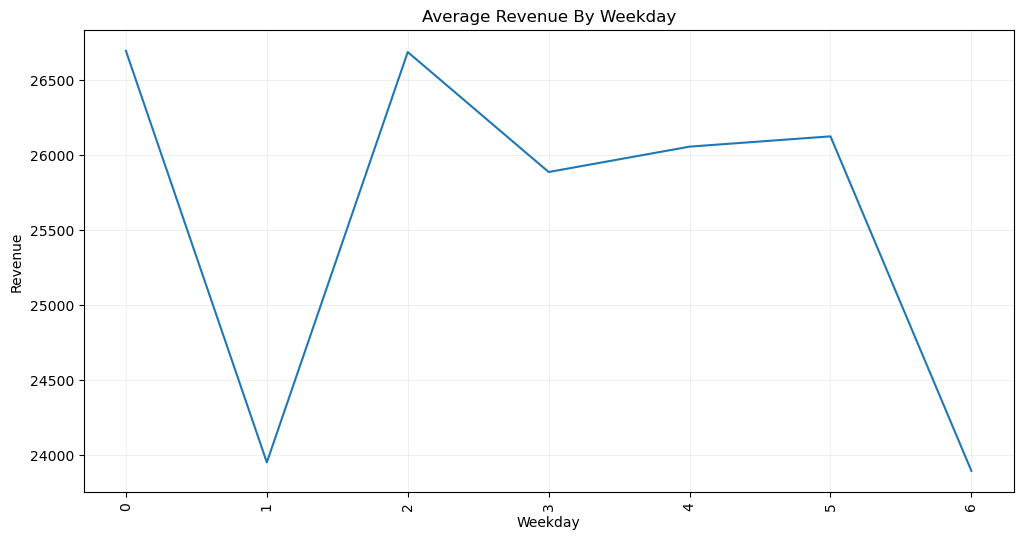

In [26]:
weekday_sales = daily_sales.groupby('weekday')['revenue'].mean().reset_index()

plt.figure(figsize = (12,6))
sns.lineplot(x = 'weekday', y = 'revenue', data = weekday_sales)
plt.xlabel('Weekday')
plt.xticks(rotation = 90)
plt.ylabel('Revenue')
plt.title('Average Revenue By Weekday')
plt.grid(True, alpha = 0.2)
plt.show()

<h1> Train-test split (time based) </h1>
<p> The dataset is split chronologically instead of randomly to prevent data leakage and simulate real-world forecasting. </p>

In [27]:
train = daily_sales[daily_sales['date'] < '2018-01-01']
test = daily_sales[daily_sales['date'] >= '2018-01-01']

Features and Target

In [28]:
x_train = train[['month', 'day', 'weekday', 'is_weekend']]
y_train = train['revenue']

x_test = test[['month', 'day', 'weekday', 'is_weekend']]
y_test = test['revenue']

<h1> Train Linear Regression </h1>

In [54]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

lr_preds = lr.predict(x_test)

<h1> Train Random Forest </h1>

In [55]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(x_train, y_train)

rf_preds = rf.predict(x_test)

<h1> Evaluate models </h1>

In [31]:
from sklearn.metrics import mean_squared_error

Linear regression RMSE:

In [32]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

Random Forest RMSE :

In [33]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

Compare

In [34]:
print("Linear Regression RMSE:", lr_rmse)
print("Random Forest RMSE:", rf_rmse)

Linear Regression RMSE: 13751.545194727349
Random Forest RMSE: 14688.712393226999


<h1> Plot prediction vs actual </h1>

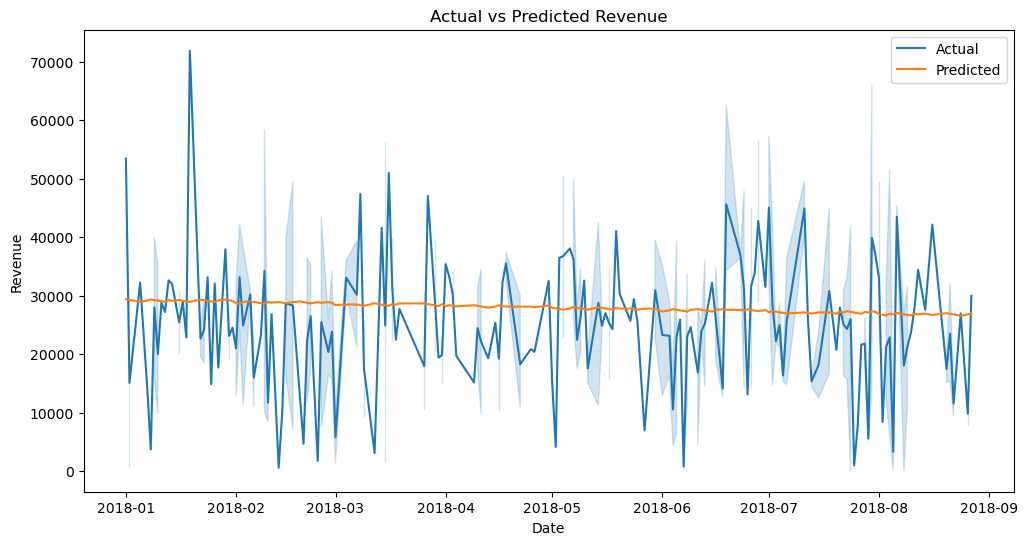

In [51]:
plt.figure(figsize=(12,6))

sns.lineplot(x=test["date"], y=y_test, label="Actual")
sns.lineplot(x=test["date"], y=lr_preds, label="Predicted")

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

---
# Model Evaluation and Insights

## Model Comparison

Two machine learning models were trained to predict daily e-commerce revenue:

### Linear Regression
Linear Regression is a statistical model that assumes a **linear relationship between input features and the target variable (revenue)**.

Advantages:
- Simple and fast to train
- Easy to interpret
- Works well when relationships between variables are relatively straightforward

Limitations:
- Cannot capture highly complex or nonlinear relationships in the data.

---

### Random Forest Regressor
Random Forest is an ensemble learning method that builds **multiple decision trees and combines their predictions**.

Advantages:
- Can capture nonlinear patterns
- Handles complex interactions between features
- Often performs well on many real-world datasets

Limitations:
- More computationally expensive
- Harder to interpret compared to linear models
- May overfit if the dataset or features do not contain strong nonlinear signals

---

## Model Performance Comparison

Model performance was evaluated using **RMSE (Root Mean Squared Error)**.

RMSE measures the **average prediction error** between the model’s predicted revenue and the actual revenue values.  
Lower RMSE indicates better model performance.

Results:

| Model | RMSE |
|------|------|
| Linear Regression | 13,751 |
| Random Forest | 14,688 |

Since **Linear Regression produced the lower RMSE**, it performed better for this dataset.

This indicates that the relationship between the time-based features (month, day, weekday, weekend) and daily revenue is **relatively simple and mostly linear**, which allowed the Linear Regression model to capture the pattern effectively.

---

# Interpretation of Visualizations

## Daily Revenue Trend

This plot shows how revenue changes over time.

Insights we can observe:

- Overall fluctuations in daily revenue
- Possible seasonal trends
- Periods of higher or lower sales activity

This visualization helps identify **general sales behavior and temporal patterns** in the dataset.

---

## Monthly Revenue Analysis

This visualization shows the **average daily revenue for each month**.

It helps answer questions such as:

- Which months typically generate higher sales?
- Are there seasonal trends in revenue?

Businesses can use this information to plan:

- inventory levels
- promotional campaigns
- staffing requirements

---

## Weekday Revenue Analysis

This plot compares **average revenue by weekday**.

Insights that can be derived:

- Certain days of the week may consistently generate higher sales
- Weekends may show different purchasing behavior compared to weekdays

These patterns help businesses optimize:

- marketing campaigns
- operational planning
- delivery and logistics schedules

---

## Actual vs Predicted Sales

This visualization compares:

- Actual daily revenue
- Revenue predicted by the model

A strong forecasting model should follow the **same trend direction** as the real sales data.

Even if exact values are not perfectly matched, the predicted line should:

- rise when actual sales rise
- fall when actual sales fall

This indicates the model successfully learned the **underlying sales patterns**.

---

# Business Insights

From this analysis we can conclude:

1. E-commerce sales show clear **time-based patterns** influenced by calendar features.
2. Certain months and weekdays consistently produce higher revenue.
3. Simple time-based features are sufficient to capture a large portion of the revenue variation.
4. In this dataset, a **Linear Regression model performed slightly better than Random Forest**, suggesting the relationship between time features and sales is relatively straightforward.

---

# Conclusion

This project demonstrates how historical e-commerce transaction data can be transformed into a **sales forecasting model**.

Key skills demonstrated in this project include:

- Data cleaning and preprocessing
- Merging relational datasets
- Feature engineering using time-based variables
- Exploratory data analysis and visualization
- Machine learning model training
- Model evaluation and comparison
- Deriving actionable business insights

Sales forecasting plays a critical role in retail and e-commerce industries by enabling organizations to make **data-driven decisions for inventory management, staffing, marketing strategies, and financial planning**.